In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip freeze > '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/xgboost_energia_eolica_grisearch_requirements.txt'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np
import folium
import time

In [ ]:
# --- Etapa 1: Carregando Dados---
print("--- Iniciando Etapa 1: Preparação ---")
try:
    df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/FACT_LOCALIDADE_CLIMA_202509272358.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'FACT_LOCALIDADE_CLIMA_202509272358.csv' não encontrado.")
    exit()
df_train.columns = [col.replace('"', '').lower() for col in df_train.columns]
df_train.dropna(inplace=True)

# Adiciona as novas features baseadas em data
df_train['data'] = pd.to_datetime(df_train['data'])
df_train['mes'] = df_train['data'].dt.month
df_train['dia_do_ano'] = df_train['data'].dt.dayofyear
print("Novos atributos 'mes' e 'dia_do_ano' criados.")

# Define a lista de features, incluindo as novas
target = 'wind_speed_10m_mean'
features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'surface_pressure_mean',
    'shortwave_radiation_sum', 'precipitation_sum',
    'mes', 'dia_do_ano'
]
print("\nFeatures que serão usadas:", features)

X = df_train[features]
y = df_train[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Iniciando Etapa 1: Preparação ---
Novos atributos 'mes' e 'dia_do_ano' criados.

Features que serão usadas: ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'shortwave_radiation_sum', 'precipitation_sum', 'mes', 'dia_do_ano']


In [ ]:
# --- Etapa 2: Otimização de Hiperparâmetros do XGBoost com Grid Search ---
print("\n--- Iniciando Etapa 2: Otimizando com Grid Search para XGBoost ---")

# Hiperparâmetros específica para o XGBoost
param_grid = {
    'n_estimators': [100, 200],         # Número de árvores (rodadas de boosting)
    'max_depth': [3, 5, 7],             # Profundidade máxima das árvores
    'learning_rate': [0.1, 0.05],       # Taxa de aprendizado
    'subsample': [0.7, 1.0],            # Fração de amostras usadas para treinar cada árvore
    'colsample_bytree': [0.7, 1.0]      # Fração de features usadas para treinar cada árvore
}

# Configurando e executando o Grid Search para o XGBRegressor
grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Inicia a busca pelos melhores hiperparâmetros para XGBoost... Isso pode levar vários minutos.")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"Grid Search concluído em {(end_time - start_time):.2f} segundos.")

# Guarda o melhor modelo encontrado
best_xgb_model = grid_search.best_estimator_
print("\nMelhores parâmetros encontrados:")
print(grid_search.best_params_)


--- Iniciando Etapa 2: Otimizando com Grid Search para XGBoost ---
Inicia a busca pelos melhores hiperparâmetros para XGBoost... Isso pode levar vários minutos.
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Grid Search concluído em 190.60 segundos.

Melhores parâmetros encontrados:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}


In [ ]:
# --- Etapa 3: Avaliando o Modelo XGBoost Otimizado ---
print("\n--- Iniciando Etapa 3: Avaliação do Modelo XGBoost Final ---")
y_pred = best_xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nResultados da Avaliação do Modelo XGBoost OTIMIZADO:")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f} MJ/m²")


--- Iniciando Etapa 3: Avaliação do Modelo XGBoost Final ---

Resultados da Avaliação do Modelo XGBoost OTIMIZADO:
R² (Coeficiente de Determinação): 0.7962
MSE (Erro Quadrático Médio): 7.4606
RMSE (Raiz do Erro Quadrático Médio): 2.7314 MJ/m²


In [ ]:
# --- Etapa 4: Salvando o Modelo Otimizado ---
print("\n--- Iniciando Etapa 4: Salvando o Modelo XGBoost Final ---")
model_filename_final_xgb = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/final_xgboost_eolica.joblib'
joblib.dump(best_xgb_model, model_filename_final_xgb)
print(f"Modelo salvo como: {model_filename_final_xgb}")


--- Iniciando Etapa 4: Salvando o Modelo XGBoost Final ---
Modelo salvo como: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/final_xgboost_eolica.joblib


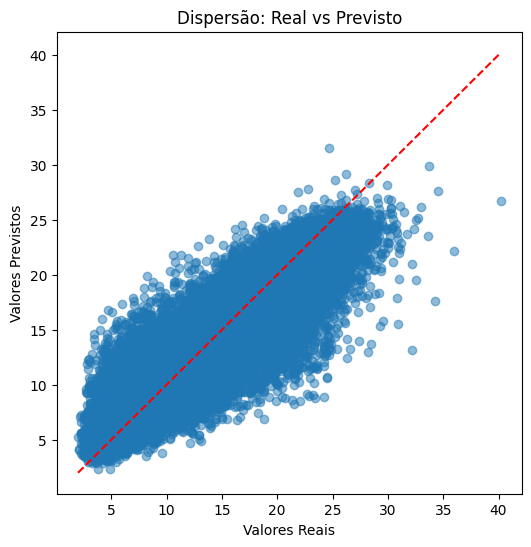

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Dispersão: Real vs Previsto')
plt.show()

In [ ]:
# --- Etapa 5: Prevendo e gerando o Mapa com o Modelo Final ---
print("\n--- Iniciando Etapa 5: Previsão e Mapeamento com o Modelo XGBoost Final ---")
try:
    df_goias = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/goias_clima_era5_diario_completo.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'goias_clima_era5_diario_completo.csv' não encontrado.")
    exit()
if df_goias[features[:-2]].isnull().sum().any():
    df_goias.dropna(subset=features[:-2], inplace=True)

# Aplica a mesma engenharia de atributos nos dados de Goiás
df_goias['time'] = pd.to_datetime(df_goias['time'])
df_goias['mes'] = df_goias['time'].dt.month
df_goias['dia_do_ano'] = df_goias['time'].dt.dayofyear
print("Engenharia de atributos aplicada aos dados de Goiás.")

X_goias = df_goias[features]
loaded_final_model_xgb = joblib.load(model_filename_final_xgb)
df_goias['VELOCIDADE_VENTO_PREDITA_FINAL'] = loaded_final_model_xgb.predict(X_goias)
results_filename_final_xgb = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/previsoes_eolica_goias_final_xgb.csv'
df_goias.to_csv(results_filename_final_xgb, index=False)
print(f"Previsões salvas em: {results_filename_final_xgb}")

# Geração do mapa
potencial_solar_final_xgb = df_goias.groupby('municipio').agg(
    radiacao_media=('VELOCIDADE_VENTO_PREDITA_FINAL', 'mean'),
    lat=('lat', 'first'),
    lon=('lon', 'first')
).reset_index()
top_final_xgb = potencial_solar_final_xgb.sort_values(by='radiacao_media', ascending=False).head(10)

mapa_goias_final_xgb = folium.Map(location=[-15.98, -49.86], zoom_start=7, tiles='OpenStreetMap')
for index, row in top_final_xgb.iterrows():
    popup_text = f"<b>Município:</b> {row['municipio']}<br><b>Radiação Média (XGB Otimizado):</b> {row['radiacao_media']:.2f} MJ/m²"
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=folium.Tooltip(
            text=row['municipio'], permanent=True, direction='top',
            offset=[0, -10], style="font-weight:bold; font-size:10px;"
        )
    ).add_to(mapa_goias_final_xgb)
mapa_filename_final_xgb = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/mapa_potencial_eolica_final_xgb.html'
mapa_goias_final_xgb.save(mapa_filename_final_xgb)
print(f"\nMapa final salvo como '{mapa_filename_final_xgb}'.")

mapa_goias_final_xgb


--- Iniciando Etapa 5: Previsão e Mapeamento com o Modelo XGBoost Final ---
Engenharia de atributos aplicada aos dados de Goiás.
Previsões salvas em: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/previsoes_eolica_goias_final_xgb.csv

Mapa final salvo como '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/10.XGBoost_Grid_Search/arquivos_gerados/mapa_potencial_eolica_final_xgb.html'.
